Data loaded: 7043 rows and 21 columns

--- FIRST 5 ROWS ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  

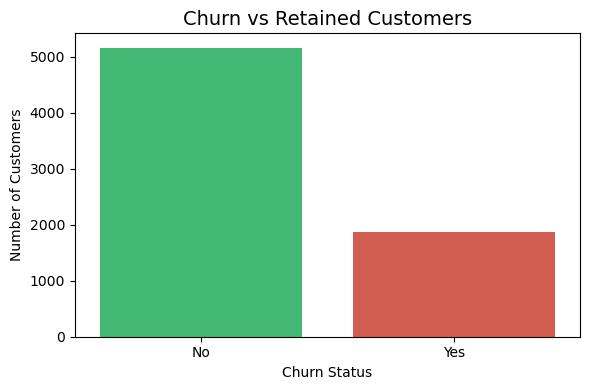


Chart saved as 'Telco_Customer_Churn_overview.png'

🎉 PHASE 1 COMPLETE — Ready for SQL and EDA!


In [1]:
# ============================================================
# PHASE 1 — DATA LOADING & CLEANING
# Project: Cancel Culture — Customer Churn Analysis
# Dataset: IBM Telco Customer Churn
# ============================================================
# HOW TO USE THIS FILE:
# 1. Download dataset from Kaggle: 
#    https://www.kaggle.com/datasets/blastchar/telco-customer-churn
# 2. Save the CSV file in the same folder as this script
# 3. Run this script in Jupyter Notebook or VS Code
# ============================================================

# --- STEP 1: IMPORT LIBRARIES ---
# Pandas = your main tool for working with data tables
# Matplotlib/Seaborn = for making charts

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




# --- STEP 2: LOAD THE DATA ---
# pd.read_csv() reads your CSV file into a DataFrame
# A DataFrame is like an Excel table inside Python

df = pd.read_csv('/Users/hinahaq/Downloads/Final_Project/Raw_data/Telco_Customer_Churn.csv')

print(f"Data loaded: {df.shape[0]} rows and {df.shape[1]} columns")


# --- STEP 3: FIRST LOOK AT THE DATA ---
# Always do this first — understand what you are working with
# before touching anything

print("\n--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- COLUMN NAMES ---")
print(df.columns.tolist())

print("\n--- DATA TYPES ---")
print(df.dtypes)

print("\n--- BASIC STATS ---")
print(df.describe())


# --- STEP 4: CHECK FOR MISSING VALUES ---
# Missing values = empty cells that can break your analysis

print("\n--- MISSING VALUES PER COLUMN ---")
missing = df.isnull().sum()
print(missing[missing > 0])  # Only show columns that HAVE missing values

# Note: TotalCharges column often has spaces instead of NaN
# We fix this below


# --- STEP 5: FIX THE TOTALCHARGES COLUMN ---
# This column should be a number but Kaggle stores it as text
# We convert it to a number and handle any empty strings

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# errors='coerce' means: if a value cannot be converted, turn it into NaN

# Now drop rows where TotalCharges is still missing (usually ~11 rows)
rows_before = len(df)
df = df.dropna(subset=['TotalCharges'])
rows_after = len(df)

print(f"\nDropped {rows_before - rows_after} rows with missing TotalCharges")


# --- STEP 6: CONVERT CHURN COLUMN TO NUMBERS ---
# Machine learning needs numbers, not Yes/No text
# We create a new column: 1 = churned, 0 = stayed

df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\n--- CHURN DISTRIBUTION ---")
print(df['Churn'].value_counts())
print(f"\nOverall Churn Rate: {df['Churn_Binary'].mean()*100:.1f}%")


# --- STEP 7: DROP CUSTOMERID COLUMN ---
# CustomerID is just a unique identifier — it has no analytical value
# Keeping it would confuse your analysis

df = df.drop(columns=['customerID'])
print("\nDropped customerID column")


# --- STEP 8: CHECK FINAL CLEANED DATA ---

print("\n--- FINAL DATA SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- ANY REMAINING MISSING VALUES? ---")
print(df.isnull().sum().sum(), "missing values remaining")

print("\n--- COLUMN DATA TYPES AFTER CLEANING ---")
print(df.dtypes)


# --- STEP 9: SAVE CLEANED DATA ---
# Save your cleaned version so you don't have to redo this every time

df.to_csv('/Users/hinahaq/Downloads/Final_Project/Clean_data/Telco_Customer_Churn_cleaned.csv', index=False)
print("\nCleaned data saved as 'Telco_Customer_Churn_cleaned.csv'")


# --- STEP 10: QUICK FIRST VISUAL ---
# Just a simple churn count chart to confirm everything looks right

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, legend=False)
plt.title('Churn vs Retained Customers', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('/Users/hinahaq/Downloads/Final_Project/Clean_data/Telco_Customer_Churn_overview.png', dpi=150)
plt.show()

print("\nChart saved as 'Telco_Customer_Churn_overview.png'")
print("\n🎉 PHASE 1 COMPLETE — Ready for SQL and EDA!")

In [3]:
df.isnull().sum()


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_Binary        0
dtype: int64

In [12]:
#Banking Churn Data cleaning

df_bank = pd.read_csv('/Users/hinahaq/Downloads/Final_Project/Raw_data/Bank_Churn_Modelling.csv')
print(df_bank.shape)
print(df_bank.columns.tolist())
print(df_bank.head(3))
print(df_bank.dtypes)
print(df_bank.isnull().sum())

(10000, 14)
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           

In [4]:
# ============================================================
# PHASE 1 — BANK DATA CLEANING
# Project: Cancel Culture — Customer Churn Analysis
# Dataset: Bank Customer Churn 
# ============================================================



# --- STEP 1: LOAD DATA ---
df_bank = pd.read_csv('/Users/hinahaq/Downloads/Final_Project/Raw_data/Bank_Churn_Modelling.csv')
print(f"Data loaded: {df_bank.shape[0]} rows, {df_bank.shape[1]} columns")


# --- STEP 2: DROP USELESS COLUMNS ---
# RowNumber = just a row counter, no analytical value
# CustomerId = unique identifier, no analytical value
# Surname = personal data, no analytical value

df_bank = df_bank.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print("Dropped RowNumber, CustomerId, Surname")


# --- STEP 3: RENAME COLUMNS ---
# Rename 'Exited' to 'Churn_Binary' to match Telco dataset naming
# This makes cross-dataset analysis easier later

df_bank = df_bank.rename(columns={'Exited': 'Churn_Binary'})

# Also add a readable Churn column like Telco has
df_bank['Churn'] = df_bank['Churn_Binary'].map({1: 'Yes', 0: 'No'})
print("Renamed Exited to Churn_Binary, added Churn column")


# --- STEP 4: ADD PLATFORM LABEL ---
# We will merge Telco and Bank later
# So we need a column that identifies which dataset each row came from

df_bank['Industry'] = 'Banking'
print("Added Industry column: Banking")


# --- STEP 5: CONFIRM CHURN DISTRIBUTION ---
print("\n--- CHURN DISTRIBUTION ---")
print(df_bank['Churn'].value_counts())
print(f"\nOverall Churn Rate: {df_bank['Churn_Binary'].mean()*100:.1f}%")


# --- STEP 6: QUICK COLUMN OVERVIEW ---
print("\n--- FINAL COLUMNS ---")
print(df_bank.columns.tolist())

print("\n--- DATA TYPES ---")
print(df_bank.dtypes)

print("\n--- MISSING VALUES ---")
print(df_bank.isnull().sum().sum(), "missing values")


# --- STEP 7: SAVE CLEANED FILE ---
save_path = os.path.join(os.path.expanduser('~'), 'Desktop', 'bank_churn_cleaned.csv')
df_bank.to_csv(save_path, index=False)
print(f"Saved to: {save_path}")
print("\nSaved as 'bank_churn_cleaned.csv'")
print("\nBANK PHASE 1 COMPLETE!")




Data loaded: 10000 rows, 14 columns
Dropped RowNumber, CustomerId, Surname
Renamed Exited to Churn_Binary, added Churn column
Added Industry column: Banking

--- CHURN DISTRIBUTION ---
Churn
No     7963
Yes    2037
Name: count, dtype: int64

Overall Churn Rate: 20.4%

--- FINAL COLUMNS ---
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Churn_Binary', 'Churn', 'Industry']

--- DATA TYPES ---
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Churn_Binary         int64
Churn               object
Industry            object
dtype: object

--- MISSING VALUES ---
0 missing values
Saved to: /Users/hinahaq/Desktop/bank_churn_cleaned.csv

Saved as 'bank_churn_cleaned.csv'

BANK PHASE 1 COMPLET